# Exercise 5: Monthly Department Forecasting

Forecasts monthly revenue by department with a seasonal naive baseline and an AutoARIMA statistical model.

,Model Name,Implementation,Split,MAE,RMSE,MAPE,OPE,R2
0,SeasonalNaive,custom/statsforecast,Val,36505.983452,54308.004874,10.052765,-0.066550,0.978758
1,SeasonalNaive,custom/statsforecast,Test,66986.413214,87226.785416,13.953724,-0.110293,0.948740
2,AutoARIMA,custom/statsforecast,Val,61132.861740,119543.567035,11.655366,0.068729,0.897078
3,AutoARIMA,custom/statsforecast,Test,41661.025767,59559.432710,9.356731,-0.040796,0.976101


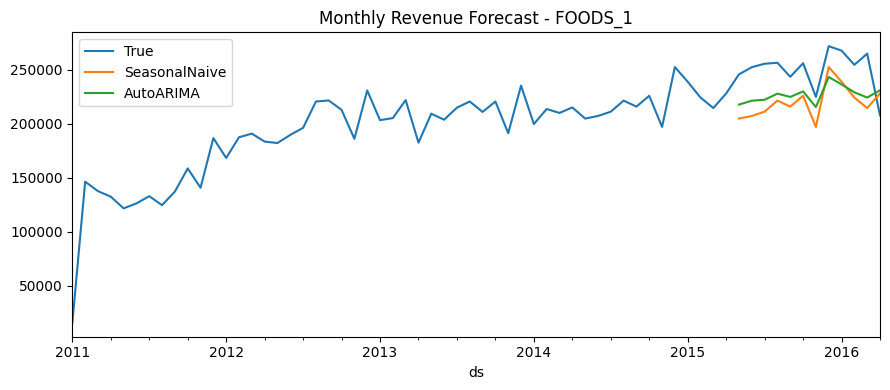

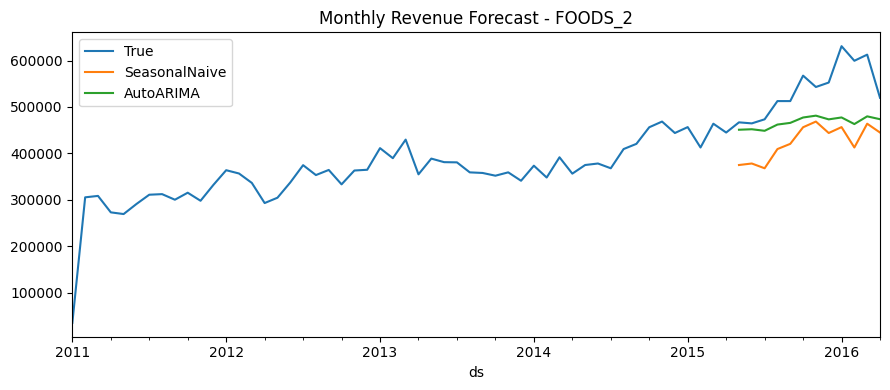

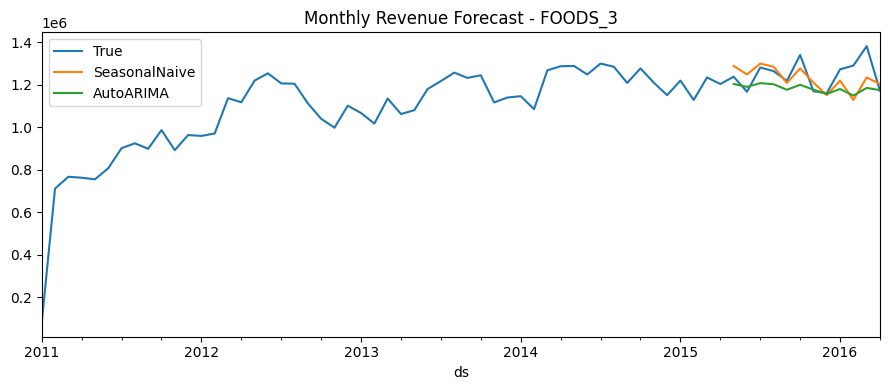

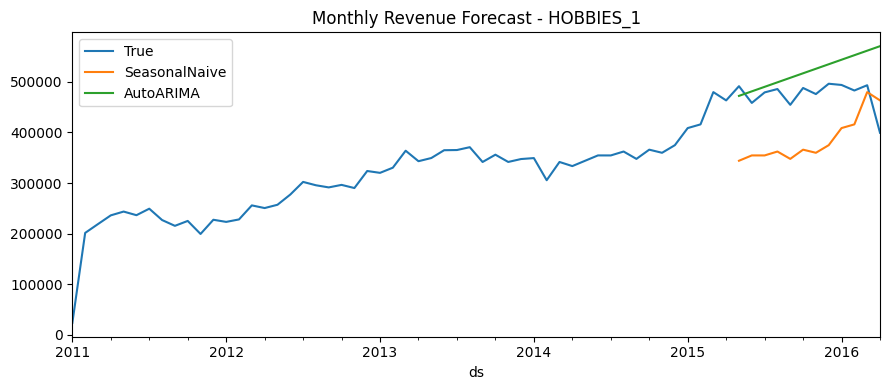

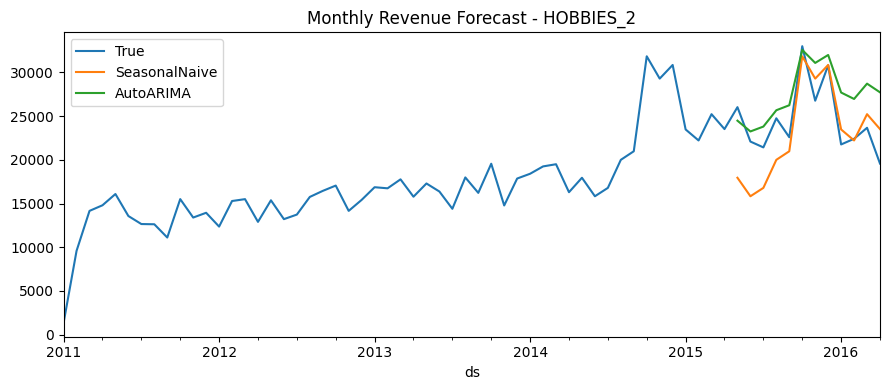

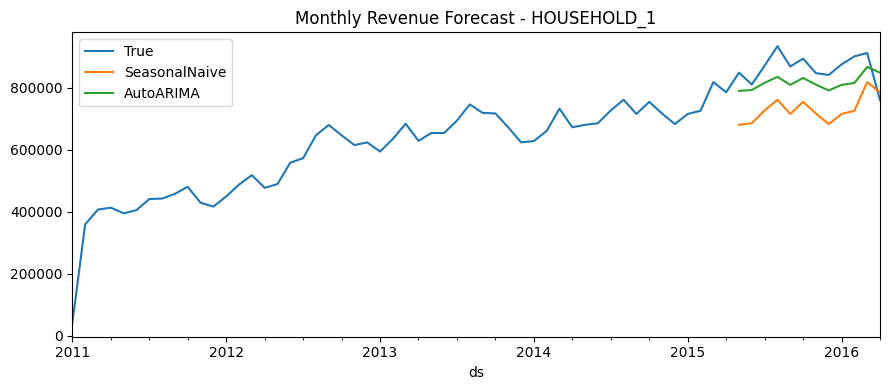

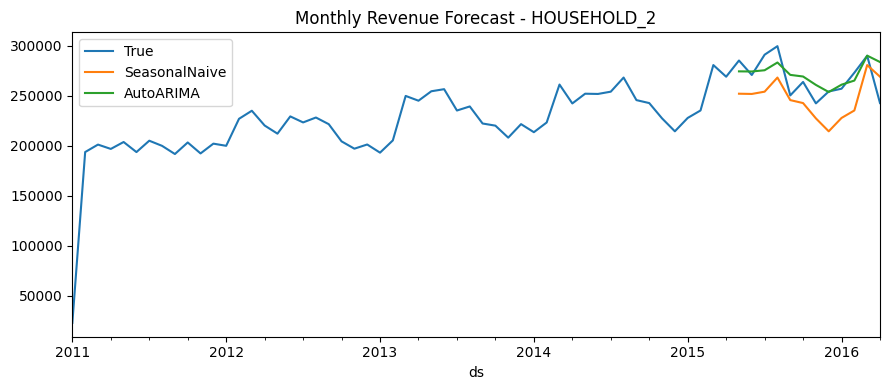

In [1]:
import pandas as pd

from tis3il.m5_utils import DOC_ASSETS, PATHS, PROCESSED, ensure_dirs, load_parquet, metrics, seasonal_naive, split_last_periods

def moving_average(train: pd.DataFrame, future: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    out = []
    for uid, hist in train.sort_values("ds").groupby("unique_id", sort=False):
        horizon = future[future["unique_id"] == uid].copy()
        horizon["y_pred"] = hist["y"].tail(window).mean()
        out.append(horizon)
    return pd.concat(out, ignore_index=True)

def statsforecast_autoarima(train: pd.DataFrame, future: pd.DataFrame) -> pd.DataFrame:
    try:
        from statsforecast import StatsForecast
        from statsforecast.models import AutoARIMA
    except ImportError:
        return moving_average(train, future, window=6)
    horizon = int(future.groupby("unique_id").size().min())
    sf = StatsForecast(models=[AutoARIMA(season_length=12)], freq="MS", n_jobs=1)
    pred = sf.forecast(df=train[["unique_id", "ds", "y"]], h=horizon).rename(columns={"AutoARIMA": "y_pred"})
    pred["ds"] = pd.to_datetime(pred["ds"])
    future = future.copy()
    future["ds"] = pd.to_datetime(future["ds"])
    return future[["unique_id", "ds", "y"]].merge(pred[["unique_id", "ds", "y_pred"]], on=["unique_id", "ds"], how="left")

def evaluate(name: str, split: str, pred: pd.DataFrame) -> dict[str, object]:
    return {"Model Name": name, "Implementation": "custom/statsforecast", "Split": split, **metrics(pred["y"], pred["y_pred"])}

ensure_dirs()
df = load_parquet(PATHS.dept_monthly)
df["ds"] = pd.to_datetime(df["ds"])
train, val, test = split_last_periods(df)
val_base = seasonal_naive(train, val)
test_base = seasonal_naive(pd.concat([train, val]), test)
val_stat = statsforecast_autoarima(train, val)
test_stat = statsforecast_autoarima(pd.concat([train, val]), test)
results = pd.DataFrame([
    evaluate("SeasonalNaive", "Val", val_base),
    evaluate("SeasonalNaive", "Test", test_base),
    evaluate("AutoARIMA", "Val", val_stat),
    evaluate("AutoARIMA", "Test", test_stat),
])
results.to_csv(PROCESSED / "exercise5_results.csv", index=False)

for uid in sorted(df["unique_id"].unique()):
    ax = df[df["unique_id"] == uid].plot(x="ds", y="y", figsize=(9, 4), label="True", title=f"Monthly Revenue Forecast - {uid}")
    test_base[test_base["unique_id"] == uid].plot(x="ds", y="y_pred", ax=ax, label="SeasonalNaive")
    test_stat[test_stat["unique_id"] == uid].plot(x="ds", y="y_pred", ax=ax, label="AutoARIMA")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(DOC_ASSETS / f"exercise5_{uid}.png", dpi=150)
results